<a href="https://colab.research.google.com/github/mohammad64874-boop/ML_Lab_Final_Project/blob/main/ML_Lab_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gradio pandas numpy scikit-learn matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import gradio as gr

In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

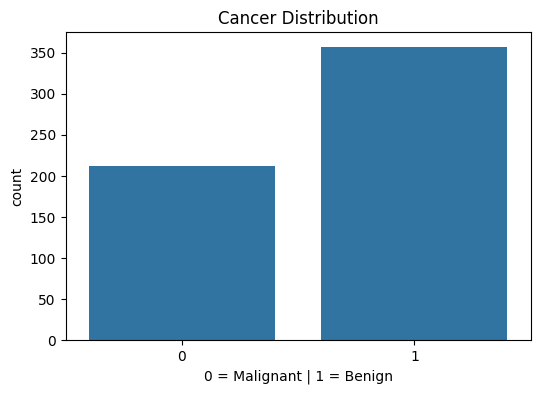

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Cancer Distribution")

plt.xlabel(
    "0 = Malignant | 1 = Benign"
)

plt.show()

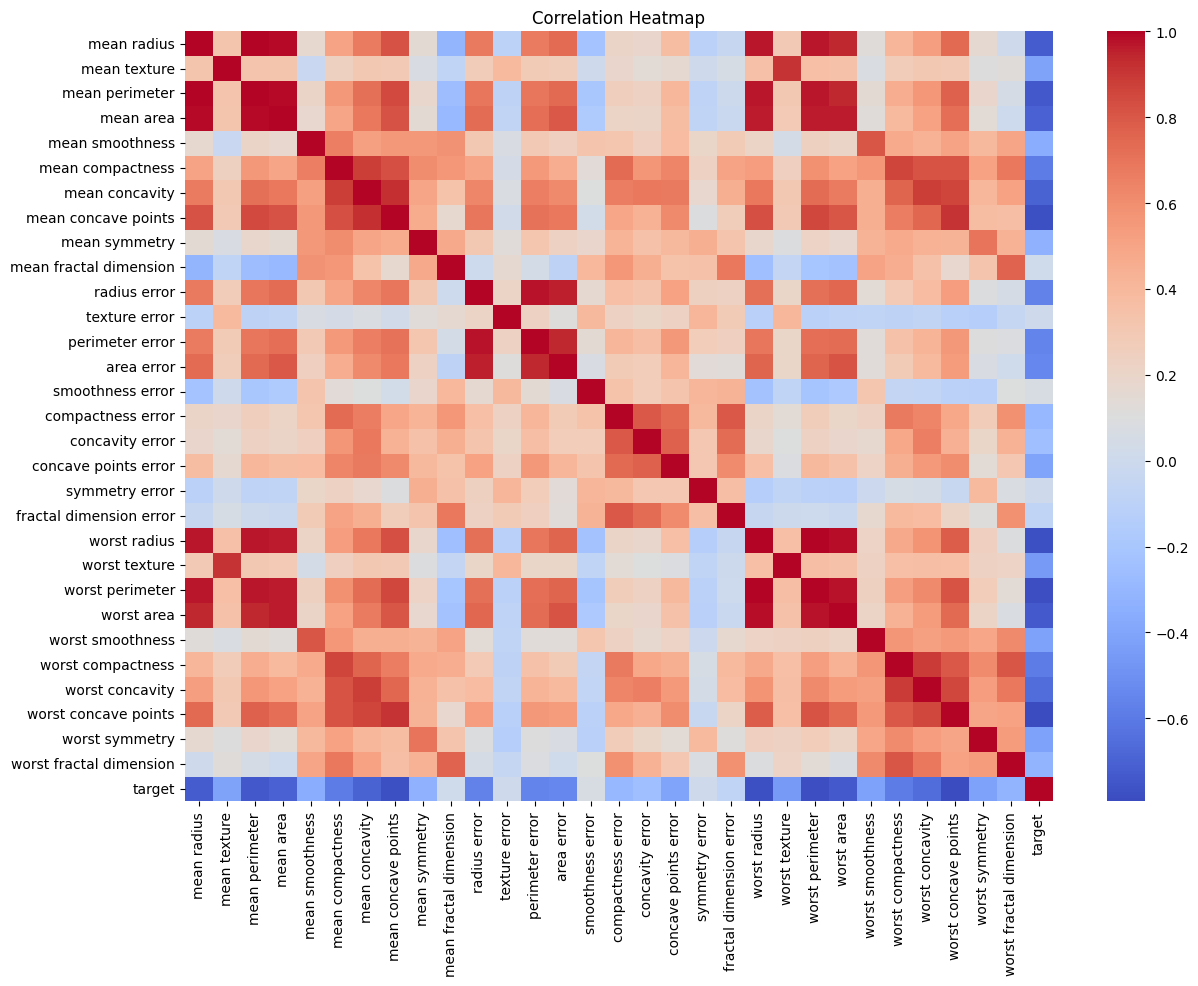

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [ ]:
selected_features = [
    "worst area",
    "worst concave points",
    "worst perimeter",
    "mean concave points",
    "worst radius"
]

X = df[selected_features]

y = df["target"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)


In [ ]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_precision = precision_score(
    y_test,
    dt_pred
)

dt_recall = recall_score(
    y_test,
    dt_pred
)

dt_f1 = f1_score(
    y_test,
    dt_pred
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Decision Tree Accuracy: 0.9473684210526315
Random Forest Accuracy: 0.956140350877193


In [ ]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Decision Tree":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],

    "Random Forest":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.947368,0.956140
1,Precision,0.945205,0.958333
2,Recall,0.971831,0.971831
3,F1 Score,0.958333,0.965035


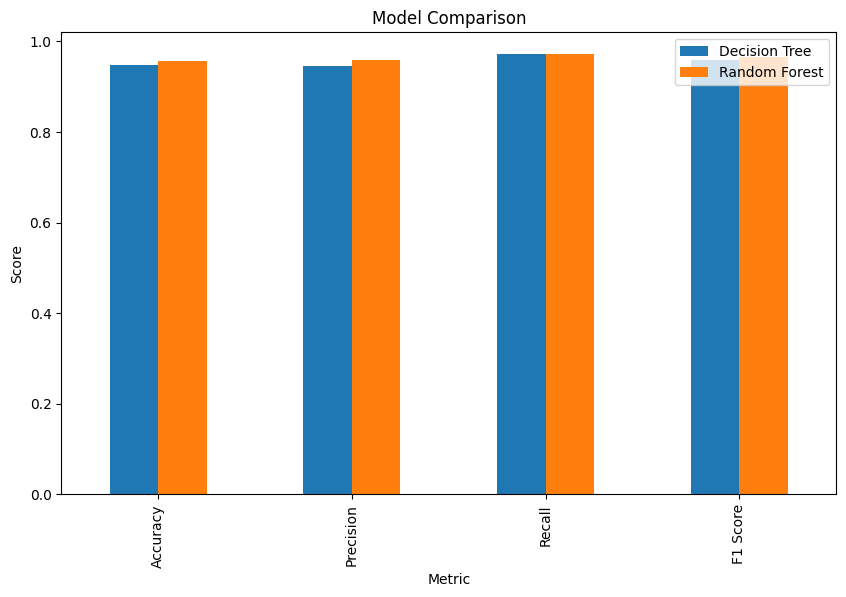

In [ ]:
comparison.set_index(
    "Metric"
).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.show()

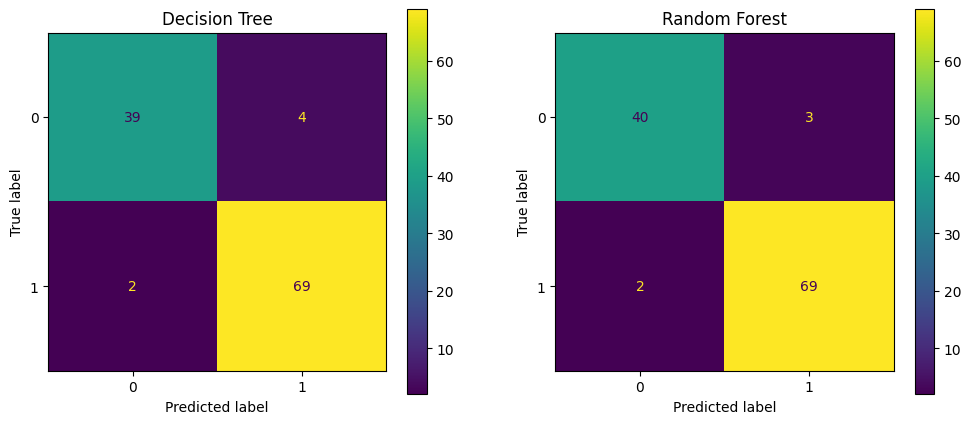

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    ax=ax[0]
)

ax[0].set_title(
    "Decision Tree"
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    ax=ax[1]
)

ax[1].set_title(
    "Random Forest"
)

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature": selected_features,

    "Importance":
    rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,worst perimeter,0.258714
1,worst concave points,0.235898
3,mean concave points,0.193473
0,worst area,0.181909
4,worst radius,0.130007


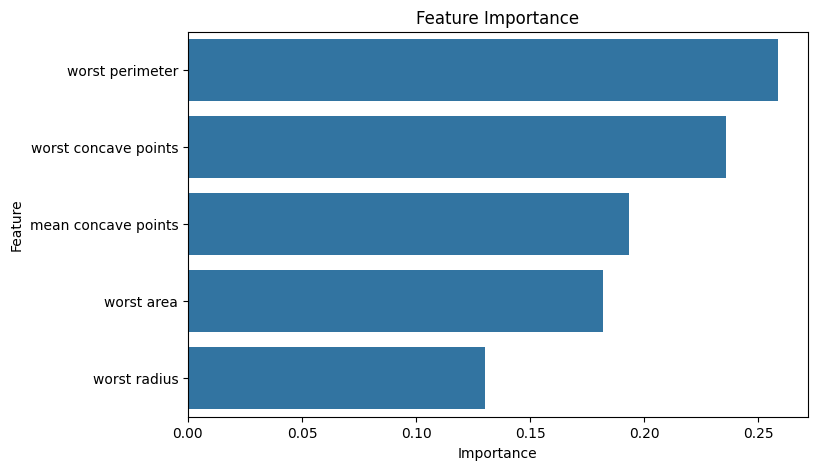

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

In [ ]:
comparison_text = f"""
MODEL COMPARISON REPORT

Decision Tree

Accuracy  : {dt_accuracy:.4f}
Precision : {dt_precision:.4f}
Recall    : {dt_recall:.4f}
F1 Score  : {dt_f1:.4f}

--------------------------------

Random Forest

Accuracy  : {rf_accuracy:.4f}
Precision : {rf_precision:.4f}
Recall    : {rf_recall:.4f}
F1 Score  : {rf_f1:.4f}
"""

In [ ]:
def predict_cancer(
    worst_area,
    worst_concave_points,
    worst_perimeter,
    mean_concave_points,
    worst_radius
):

    sample = np.array([[
        worst_area,
        worst_concave_points,
        worst_perimeter,
        mean_concave_points,
        worst_radius
    ]])

    dt_prediction = dt_model.predict(sample)[0]
    rf_prediction = rf_model.predict(sample)[0]

    dt_prob = dt_model.predict_proba(sample)[0][1] * 100
    rf_prob = rf_model.predict_proba(sample)[0][1] * 100

    dt_result = (
        "Benign"
        if dt_prediction == 1
        else "Malignant"
    )

    rf_result = (
        "Benign"
        if rf_prediction == 1
        else "Malignant"
    )

    best_model = (
        "Random Forest"
        if rf_accuracy > dt_accuracy
        else "Decision Tree"
    )

    return f"""
🏥 BREAST CANCER PREDICTION DASHBOARD

══════════════════════════════════════

📊 Decision Tree

Prediction : {dt_result}

Confidence : {dt_prob:.2f}%

Accuracy   : {dt_accuracy:.2%}

══════════════════════════════════════

🌲 Random Forest

Prediction : {rf_result}

Confidence : {rf_prob:.2f}%

Accuracy   : {rf_accuracy:.2%}

══════════════════════════════════════

🏆 Best Performing Model

{best_model}

══════════════════════════════════════
"""

In [ ]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.tight_layout()

plt.savefig("comparison_chart.png")
plt.close()

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig("feature_importance.png")

plt.close()

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Cancer Distribution")

plt.tight_layout()

plt.savefig("dataset_distribution.png")

plt.close()

In [ ]:
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Breast Cancer Prediction System"
) as demo:

    gr.Markdown(
        "# 🏥 Breast Cancer Prediction System"
    )

    gr.Markdown(
        """
        Machine Learning Lab Project

        Algorithms Used:
        - Decision Tree
        - Random Forest
        """
    )

    with gr.Tab("🔍 Prediction"):

        worst_area = gr.Slider(
            0,
            50,
            value=10,
            label="Worst Area"
        )

        worst_concave_points = gr.Slider(
            0,
            0.30,
            value=0.10,
            label="Worst Concave Points"
        )

        worst_perimeter = gr.Slider(
            50,
            100,
            value=70,
            label="Worst Perimeter"
        )

        mean_concave_points = gr.Slider(
            0,
            0.25,
            value=0.05,
            label="Mean Concave Points"
        )

        worst_radius = gr.Slider(
            2,
            20,
            value=15,
            label="Worst Radius"
        )

        predict_btn = gr.Button(
            "Predict"
        )

        prediction_output = gr.Textbox(
            lines=20,
            label="Prediction Result"
        )

        predict_btn.click(
            fn=predict_cancer,
            inputs=[
                worst_area,
                worst_concave_points,
                worst_perimeter,
                mean_concave_points,
                worst_radius
            ],
            outputs=prediction_output
        )

    with gr.Tab("📊 Model Comparison"):

        gr.Textbox(
            value=comparison_text,
            lines=25,
            max_lines=35,
            label="Metrics"
        )

        gr.Image(
            "comparison_chart.png"
        )

    with gr.Tab("📈 Feature Importance"):

        gr.Image(
            "feature_importance.png"
        )

    with gr.Tab("📋 Dataset Analysis"):

        gr.Image(
            "dataset_distribution.png"
        )

/tmp/ipykernel_397/1738188298.py:1: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


In [ ]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fdadbd2485cf91f2e4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
